## Loading the Dataset

- Input matrix $X \in \mathbb{R}^{N \times 3}$  
- Target vector $y \in \mathbb{R}^{N \times 1}$  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fix random seed 
np.random.seed(0)

# Load dataset
df = pd.read_csv("./Advertising.csv")
X = df[["TV", "Radio", "Newspaper"]].to_numpy(dtype=float)
y = df[["Sales"]].to_numpy(dtype=float)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200, 1)


## Train–Test Split


- Training set (80%)  
- Test set (20%)


In [3]:
# N = total number of samples
N = X.shape[0]

# Random permutation 
perm = np.random.permutation(N)

test_size = int(0.2 * N)

X_train = X[perm[test_size:]]
y_train = y[perm[test_size:]]

X_test  = X[perm[:test_size]]
y_test  = y[perm[:test_size]]

## Feature Standardisation

$$
X_{\text{std}} = \frac{X - \mu}{\sigma}
$$

where $\mu$ and $\sigma$ are computed from the **training set only**.


In [4]:
# μ = mean of each feature
mu = X_train.mean(axis=0, keepdims=True)

# σ = standard deviation of each feature 
sd = X_train.std(axis=0, keepdims=True) + 1e-8

X_train = (X_train - mu) / sd

X_test  = (X_test - mu) / sd

## Sigmoid Activation Function

The sigmoid function is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Forward Pass

$$
z^{(1)} = XW_1^T + b_1^T
$$

$$
a^{(1)} = \sigma\!\left(z^{(1)}\right)
$$

$$
z^{(2)} = a^{(1)} W_2 + b_2
$$

$$
\hat{y} = z^{(2)} \quad \text{(linear output)}
$$


In [14]:
def forward(X, W1, b1, W2, b2):
    """
    X  : (N, 3)   N = number of data points,
    W1 : (H, 3)   H = number of hidden neurons
    b1 : (H, 1)   hidden bias
    W2 : (H, 1)   hidden -> output weights
    b2 : (1, 1)   output bias
    """
    Z1 = X @ W1.T + b1.T          # (N, H)
    
    A1 = sigmoid(Z1)              # (N, H)

    Z2 = A1 @ W2 + b2             # (N, 1)

    Yhat = Z2                     # (N, 1)

    # Return prediction and cached values
    return Yhat, (X, Z1, A1)

## Mean Squared Error Loss

$$
L = \frac{1}{2N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$


In [7]:
def mse(Yhat, y):
    N = y.shape[0]
    return (1/(2*N)) * np.sum((y - Yhat)**2)

## Backpropagation 

### Output Layer

$$
\frac{\partial L}{\partial W^{(2)}} =
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z^{(2)}}
\frac{\partial z^{(2)}}{\partial W^{(2)}}
$$

$$
\frac{\partial L}{\partial \hat{y}} = \hat{y} - y
$$

$$
\frac{\partial \hat{y}}{\partial z^{(2)}} = 1
$$

$$
\frac{\partial z^{(2)}}{\partial W^{(2)}} = a^{(1)}
$$

$$
\Rightarrow
\frac{\partial L}{\partial W^{(2)}} =
(\hat{y}-y)\, a^{(1)}
$$

---

### Hidden Layer

$$
\frac{\partial L}{\partial W^{(1)}} =
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z^{(2)}}
\frac{\partial z^{(2)}}{\partial a^{(1)}}
\frac{\partial a^{(1)}}{\partial z^{(1)}}
\frac{\partial z^{(1)}}{\partial W^{(1)}}
$$

$$
\frac{\partial z^{(2)}}{\partial a^{(1)}} = W^{(2)}
$$

$$
\frac{\partial a^{(1)}}{\partial z^{(1)}} = \sigma'(z^{(1)})
$$

$$
\frac{\partial z^{(1)}}{\partial W^{(1)}} = X
$$

$$
\Rightarrow
\frac{\partial L}{\partial W^{(1)}} =
\big((\hat{y}-y) W^{(2)T} \odot \sigma'(z^{(1)})\big)^T X
$$

In [8]:
def backward(X, Y, Yhat, Z1, A1, W2):

    N = Y.shape[0]

    dL_dYhat = (Yhat - Y) / N              # (N, 1)

    dL_dZ2 = dL_dYhat                      # (N, 1)

    dL_dW2 = A1.T @ dL_dZ2                 # (H, N) @ (N, 1) → (H, 1)

    dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True)   # (1, 1)

    dL_dA1 = dL_dZ2 @ W2.T                 # (N, 1) @ (1, H) → (N, H)

    sigmoid_prime = A1 * (1 - A1)          # (N, H)

    dL_dZ1 = dL_dA1 * sigmoid_prime        # (N, H)

    dL_dW1 = dL_dZ1.T @ X                  # (H, N) @ (N, D) → (H, D)

    dL_db1 = np.sum(dL_dZ1, axis=0, keepdims=True).T  # (H, 1)

    return dL_dW1, dL_db1, dL_dW2, dL_db2

## Training a Model with Gradient Descent


$$
W^{(1)} \leftarrow W^{(1)} - \eta \frac{\partial L}{\partial W^{(1)}}
$$

$$
b^{(1)} \leftarrow b^{(1)} - \eta \frac{\partial L}{\partial b^{(1)}}
$$

$$
W^{(2)} \leftarrow W^{(2)} - \eta \frac{\partial L}{\partial W^{(2)}}
$$

$$
b^{(2)} \leftarrow b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$$


In [9]:
def train_model(H, epochs=500, lr=0.1):

    D = 3
    W1 = 0.1*np.random.randn(H,D)
    b1 = np.zeros((H,1))
    W2 = 0.1*np.random.randn(H,1)
    b2 = np.zeros((1,1))

    for i in range(epochs):

        Yhat, cache = forward(X_train, W1, b1, W2, b2)
        Xc, Z1, A1 = cache

        dL_dW1, dL_db1, dL_dW2, dL_db2 = backward(X_train, y_train, Yhat, Z1, A1, W2)

        W1 -= lr*dL_dW1
        b1 -= lr*dL_db1
        W2 -= lr*dL_dW2
        b2 -= lr*dL_db2
        
    Ytrain,_ = forward(X_train, W1, b1, W2, b2)
    Ytest,_  = forward(X_test,  W1, b1, W2, b2)

    return mse(Ytrain, y_train), mse(Ytest, y_test)

## Selecting the Number of Hidden Units and Learning Rate

$$
H \in \{2,4,8,16,32\}
$$
$$
lr \in \{0.2,0.3\}
$$

In [10]:
hidden_list = [2, 4, 8, 16, 32]
lr_list = [0.2, 0.3]

results = []

for H in hidden_list:
    for lr in lr_list:
        
        np.random.seed(0)
        
        train_loss, test_loss = train_model(H, epochs=1000, lr=lr)
        
        results.append((H, lr, train_loss, test_loss))

results_df = pd.DataFrame(
    results,
    columns=["Hidden Units", "Learning Rate", "Train Loss", "Test Loss"]
)

best_H, best_lr, best_train, best_test = min(results, key=lambda x: x[3])

print("Best H:", best_H)
print("Best LR:", best_lr)
print("Best train loss:", best_train)
print("Best test loss:", best_test)
results_df.sort_values("Test Loss")

Best H: 32
Best LR: 0.3
Best train loss: 0.07928754552192369
Best test loss: 0.39664026316512846


,Hidden Units,Learning Rate,Train Loss,Test Loss
9,32,0.3,0.079288,0.396640
5,8,0.3,0.086122,0.497758
7,16,0.3,0.089041,0.523730
4,8,0.2,0.101219,0.549978
3,4,0.3,0.108043,0.580453
6,16,0.2,0.117590,0.607173
2,4,0.2,0.120042,0.648923
0,2,0.2,0.281188,0.723425
8,32,0.2,0.198758,0.776783
1,2,0.3,0.531548,0.887230


## Visualising Model Selection



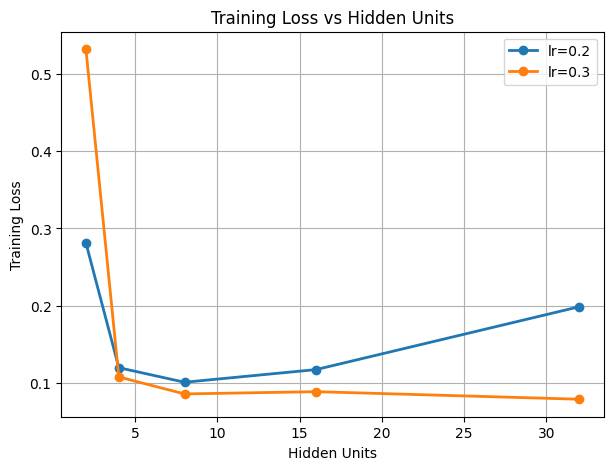

In [11]:
plt.figure(figsize=(7,5))

for lr in lr_list:
    subset = results_df[results_df["Learning Rate"] == lr]
    
    plt.plot(subset["Hidden Units"],
             subset["Train Loss"],
             marker="o",
             linewidth=2,
             label=f"lr={lr}")

plt.xlabel("Hidden Units")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Hidden Units")
plt.legend()
plt.grid(True)
plt.show()

## Final Training Using Optimal Hidden Units and Learing Rate


In [12]:
# optimal number of hidden units, and Learning Rate 
H = best_H
epochs = 1001
lr = best_lr

# Weights and baises initialisation
W1 = 0.1 * np.random.randn(H, 3)
b1 = np.zeros((H, 1))
W2 = 0.1 * np.random.randn(H, 1)
b2 = np.zeros((1, 1))

# Store losses
train_losses = []
test_losses  = []

# Gradient descent loop
for epoch in range(epochs):

    Yhat, cache = forward(X_train, W1, b1, W2, b2)
    Xc, Z1, A1 = cache
    
    dL_dW1, dL_db1, dL_dW2, dL_db2 = backward(
        X_train, y_train, Yhat, Z1, A1, W2 )

    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2

    Ytrain,_ = forward(X_train, W1, b1, W2, b2)
    Ytest,_  = forward(X_test,  W1, b1, W2, b2)

    train_losses.append(mse(Ytrain, y_train))
    test_losses.append(mse(Ytest, y_test))

    # Print progress
    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_losses[-1]:.4f} | "
            f"Test Loss: {test_losses[-1]:.4f}" )

Epoch    0 | Train Loss: 310.8827 | Test Loss: 338.9911
Epoch  100 | Train Loss: 1.3378 | Test Loss: 2.5588
Epoch  200 | Train Loss: 0.4168 | Test Loss: 1.1031
Epoch  300 | Train Loss: 0.1574 | Test Loss: 0.6208
Epoch  400 | Train Loss: 0.1240 | Test Loss: 0.5345
Epoch  500 | Train Loss: 0.1102 | Test Loss: 0.4932
Epoch  600 | Train Loss: 0.1019 | Test Loss: 0.4654
Epoch  700 | Train Loss: 0.0959 | Test Loss: 0.4445
Epoch  800 | Train Loss: 0.0911 | Test Loss: 0.4278
Epoch  900 | Train Loss: 0.0872 | Test Loss: 0.4141
Epoch 1000 | Train Loss: 0.0838 | Test Loss: 0.4025


## Learning Curves

The progress of the loss during training.


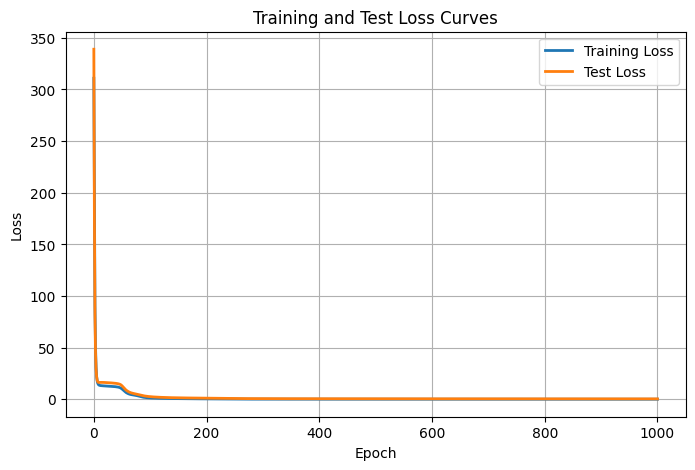

In [13]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(test_losses,  label="Test Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss Curves")

plt.legend()
plt.grid(True)
plt.show()